In [1]:
words = open('names.txt', 'r').read().splitlines()

# words[0:10]
# len(words) 
# min(len(w) for w in words) 
# max(len(w) for w in words) 

In [2]:
b = {}

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

#b


In [3]:
"""
构造 bigram 字典:
- key: tuple with two successive charactors
- value: count
"""

b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # 在安全地读取字典里某个 key 的值；如果这个 key 还不存在，就返回默认值 0

b.items()

dict_items([(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 18

In [4]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [5]:
# how often the second chr follows the first
import torch

In [6]:
a = torch.zeros((3, 5))
print(a.dtype)
a[1,3] = 2


a

torch.float32


tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 2., 0.],
        [0., 0., 0., 0., 0.]])

In [7]:

# N = torch.zeros((28, 28), dtype=torch.int32)
N = torch.zeros((27, 27), dtype=torch.int32)

In [8]:
import enum


chars = sorted(list(set(''.join(words))))

# stoi = {s:i for i,s in enumerate(chars)}
# stoi

# stoi['<S>'] = 26
# stoi['<E>'] = 27

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
# stoi

itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [9]:
for w in words:
    # chs = ['<S>'] + list(w) + ['<E>']
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] +=1

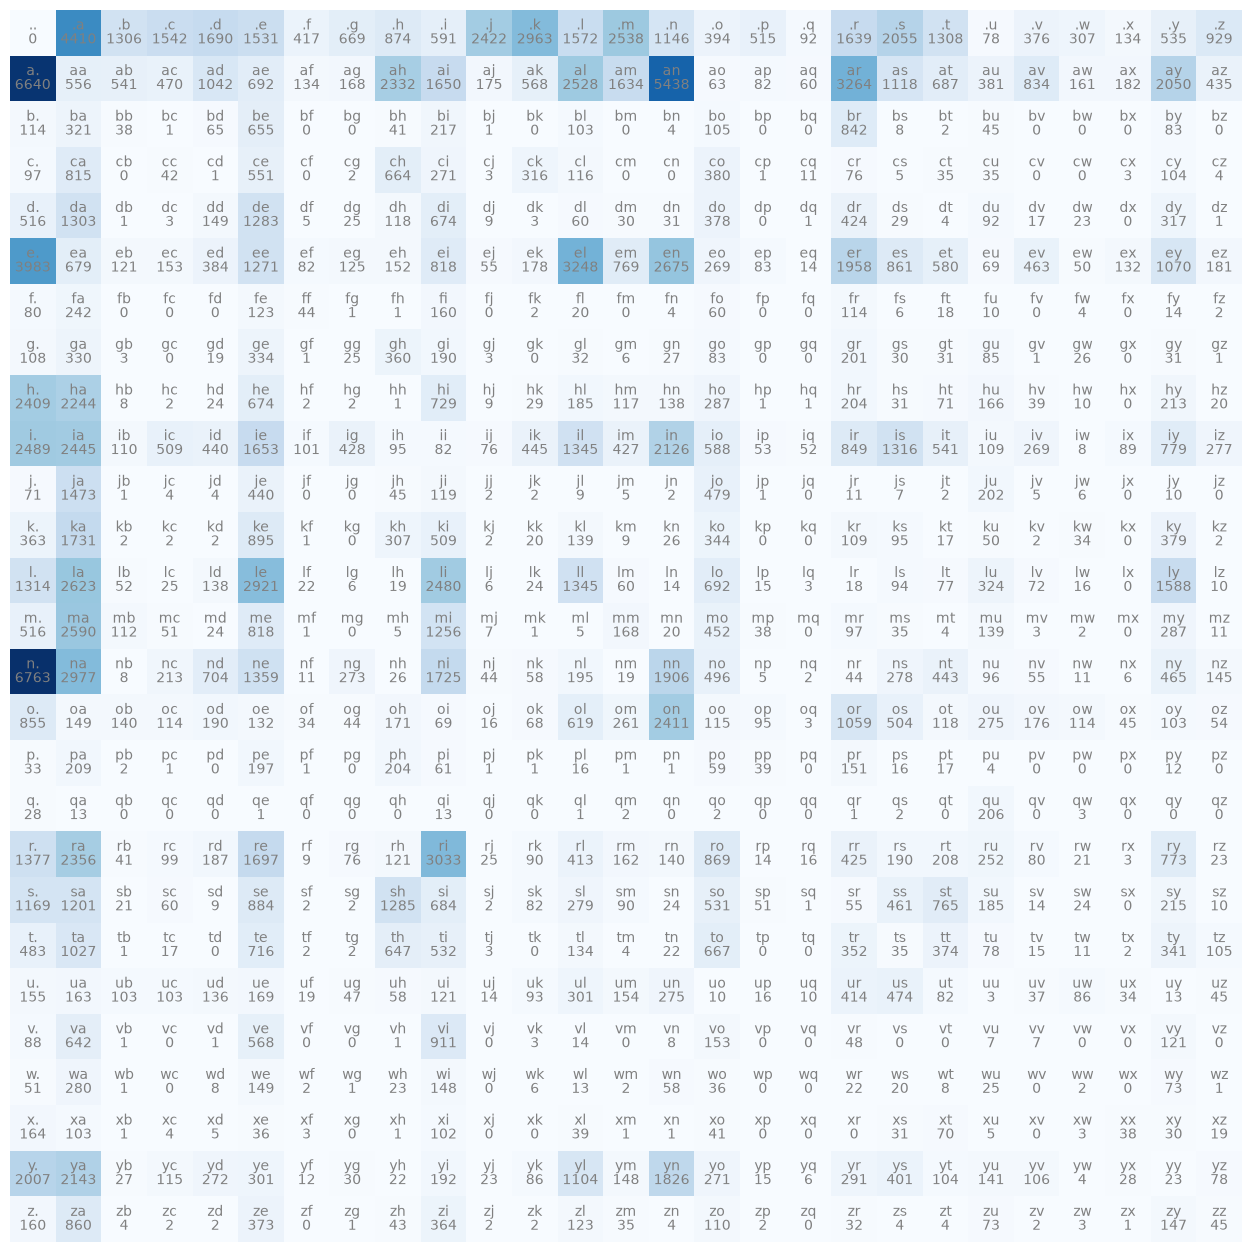

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [11]:
# N[0, :].shape
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [12]:
p = N[0].float()
p = p / p.sum()
p
# p.sum()

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [13]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [14]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [15]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [17]:
# P.sum(1, keepdim=True)

In [18]:
# 27, 27
# 27, 1 -> broadcasting -> 27, 27

# 如果没有 keepdim=True（默认为False）
# 27， 27
# 27
# 最后一个纬度对齐 ->
# 1,  27 -> broadcasting -> 27, 27 和 keepdim=True 相比转置了，即对列求和，导致结果错误

In [19]:
P = (N+1).float()
# P = P / P.sum() # it takes sum for all elements
P /= P.sum(1, keepdim=True)
# P = P / P.sum(1, keepdim=False)

In [20]:
P[0].sum()
# P[:,0].sum()

tensor(1.)

In [21]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        # p = N[ix].float()
        # p = p / p.sum()
        
        # p = torch.ones(27) / 27.0

        p = P[ix]

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [22]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [23]:
log_likelihood = 0.0
n = 0

# for w in words:
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}') # nll as loss: lower is better

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331
log_likelihood=tensor(-27.8672)
nll=tensor(27.8672)
3.4834020137786865


In [24]:
1 / 27.0

0.037037037037037035

## Part 2 NN version of Bigram

In [25]:
# create the training set of bigrams (x, y)

xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


. e
e m
m m
m a
a .


In [26]:
xs
# xs.dtype

tensor([ 0,  5, 13, 13,  1])

In [27]:
ys

tensor([ 5, 13, 13,  1,  0])

In [33]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [30]:
xenc.shape

torch.Size([5, 27])

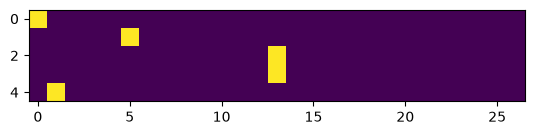

In [35]:
plt.imshow(xenc)

In [34]:
xenc.dtype

torch.float32

In [39]:
W = torch.randn((27, 27))
xenc @ W

tensor([[-0.1015,  0.9773, -2.8461,  0.5611, -0.4534,  0.8836,  0.1400,  0.5061,
          0.4062,  0.8019, -0.2996, -1.1825,  1.6524, -0.2476,  0.1241, -1.1328,
          1.0933,  0.3059,  0.4750, -1.2656,  0.7840,  0.0912, -1.5603, -0.2132,
          0.5958, -0.6018, -1.7585],
        [ 0.2188, -0.0665, -0.8843, -0.2735,  0.4669,  1.2495,  0.3165,  0.9788,
          2.1538,  0.7342, -0.2650,  0.2106,  1.6788, -0.3399,  1.0042,  0.4706,
          0.9529,  0.8718, -1.1813,  0.3533,  0.8180, -1.0052, -0.0334, -1.5321,
         -0.3651,  0.3688,  0.1589],
        [-0.1066, -0.8836,  0.1133,  0.3349,  1.6868,  1.4102, -0.5533, -0.8051,
         -0.9119,  0.5840,  0.3946,  0.8222,  1.6050, -0.3103, -1.3861,  0.5406,
          1.0680, -0.0214, -0.3956, -1.3171, -0.0173, -0.1641,  0.6827,  1.5391,
         -1.1660,  0.6198, -0.4861],
        [-0.1066, -0.8836,  0.1133,  0.3349,  1.6868,  1.4102, -0.5533, -0.8051,
         -0.9119,  0.5840,  0.3946,  0.8222,  1.6050, -0.3103, -1.3861,  0.5406

In [43]:
(xenc @ W)[3, 13]

tensor(-0.3103)

In [44]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [45]:
W[:,13]

tensor([-0.2476, -0.4633, -1.0909, -1.6876,  0.1782, -0.3399, -0.5408,  2.5859,
        -0.8354, -0.9747, -1.0735, -0.3385,  2.0154, -0.3103,  1.0696,  0.9748,
         0.4240,  0.5762, -0.8757, -0.9301, -0.6526,  0.7709,  0.6483, -2.0081,
        -0.2525, -1.0570, -0.4588])

In [46]:
(xenc[3] @ W[:,13]).sum()

tensor(-0.3103)

In [40]:
# (5, 27) @ (27, 27) -> (5, 27)

In [51]:
logits = (xenc @ W) # log-count
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0247, 0.0727, 0.0016, 0.0480, 0.0174, 0.0662, 0.0315, 0.0454, 0.0411,
         0.0610, 0.0203, 0.0084, 0.1429, 0.0214, 0.0310, 0.0088, 0.0817, 0.0372,
         0.0440, 0.0077, 0.0599, 0.0300, 0.0057, 0.0221, 0.0497, 0.0150, 0.0047],
        [0.0252, 0.0189, 0.0084, 0.0154, 0.0323, 0.0706, 0.0278, 0.0538, 0.1744,
         0.0422, 0.0155, 0.0250, 0.1084, 0.0144, 0.0552, 0.0324, 0.0525, 0.0484,
         0.0062, 0.0288, 0.0459, 0.0074, 0.0196, 0.0044, 0.0140, 0.0293, 0.0237],
        [0.0204, 0.0094, 0.0254, 0.0317, 0.1226, 0.0930, 0.0130, 0.0101, 0.0091,
         0.0407, 0.0337, 0.0516, 0.1130, 0.0166, 0.0057, 0.0390, 0.0660, 0.0222,
         0.0153, 0.0061, 0.0223, 0.0193, 0.0449, 0.1057, 0.0071, 0.0422, 0.0140],
        [0.0204, 0.0094, 0.0254, 0.0317, 0.1226, 0.0930, 0.0130, 0.0101, 0.0091,
         0.0407, 0.0337, 0.0516, 0.1130, 0.0166, 0.0057, 0.0390, 0.0660, 0.0222,
         0.0153, 0.0061, 0.0223, 0.0193, 0.0449, 0.1057, 0.0071, 0.0422, 0.0140],
        [0.0298, 0.0302,

In [53]:
probs.shape

torch.Size([5, 27])

In [54]:
probs[0].sum()

tensor(1.)

In [56]:
probs[0].shape

torch.Size([27])

In [57]:
# SUMMARY ------------------------->>>>

In [58]:
xs

tensor([ 0,  5, 13, 13,  1])

In [59]:
ys

tensor([ 5, 13, 13,  1,  0])

In [81]:
# randomly initialize 27  neurons' weights. each neuron received 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [82]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [83]:
prob.shape

torch.Size([5, 27])

In [84]:

nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character:

In [85]:
# --------- !!! OPTIMIZATION !!! yay --------------

In [86]:
xs

tensor([ 0,  5, 13, 13,  1])

In [87]:
ys

tensor([ 5, 13, 13,  1,  0])

In [101]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [132]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(5), ys].log().mean()


In [136]:
print(loss.item())

3.66926646232605


In [134]:
# backward pass
W.grad = None # set to zero the gradient
loss.backward()

In [135]:
W.data += -0.1 * W.grad

In [131]:
print(loss.item())

3.6891887187957764


In [137]:
# --------- !!! OPTIMIZATION !!! yay, but this time actually --------------

In [143]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [151]:
(W**2).mean()

tensor(1.5577, grad_fn=<MeanBackward0>)

In [155]:
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

2.4988598823547363
2.498854398727417
2.4988489151000977
2.4988436698913574
2.4988386631011963
2.498833656311035
2.4988279342651367
2.4988229274749756
2.4988181591033936
2.498812675476074
2.4988081455230713
2.49880313873291
2.498798131942749
2.498793601989746
2.498788595199585
2.498783826828003
2.498779058456421
2.498774528503418
2.498769760131836
2.498765230178833
2.498760938644409
2.4987564086914062
2.4987518787384033
2.4987475872039795
2.4987432956695557
2.498739242553711
2.498734712600708
2.498730421066284
2.4987266063690186
2.4987223148345947
2.49871826171875
2.4987144470214844
2.4987101554870605
2.4987056255340576
2.498701810836792
2.4986984729766846
2.49869441986084
2.498690605163574
2.4986863136291504
2.498682737350464
2.4986793994903564
2.4986751079559326
2.498671770095825
2.4986684322357178
2.498664140701294
2.4986608028411865
2.4986572265625
2.4986538887023926
2.498650312423706
2.4986472129821777
2.498643636703491
2.4986398220062256
2.4986369609832764
2.4986331462860107
2.498

In [157]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
